# Bootstrap og ensidig ANOVA

Denne notatboken inneholder to selvstendige utvidelser til
Foldnes Statistikk og dataanalyse (kap. 13–18):

- **Bootstrap**: konfidensintervall uten formler, illustrert med
  høydedataene fra kap. 13.5.1 og andelsdataene fra oppgave 17.6.
- **Ensidig ANOVA**: sammenligning av tre eller flere gruppegjennomsnitt,
  med et manuelt regnet eksempel og et ekte datasett (HELPrct).



In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(2026)  # for reproduserbare bootstrap-resultater
plt.rcParams["figure.figsize"] = (6, 3.5)

---
## Bootstrap-eksempel: konfidensintervall uten formler

Boka bruker (kap. 13.5.1) et datasett med høyder til $n=100$ tilfeldig trukne
personer: $\bar x = 175.35$ cm, $s = 10.00$ cm. Vi bruker de samme rådataene her
til å illustrere **bootstrap-metoden**, og sammenligner med det klassiske
$t$-konfidensintervallet.

**Ideen:** Vi behandler utvalget som om det *var* populasjonen, og trekker
mange nye utvalg *med tilbakelegging* fra det. For hvert bootstraputvalg regner
vi ut $\bar x^{*}$. Samlingen av alle $\bar x^{*}$-verdier kalles
**bootstrapfordelingen**, og et 95 % bootstrap-konfidensintervall er gitt ved
2.5- og 97.5-persentilen i denne fordelingen.

In [2]:
# Høydedata fra eksempel 13.3 i boka (n = 100, sortert)
heights = np.array([
    154, 157, 158, 159, 160, 161, 161, 161, 161, 162, 162, 162, 162, 162,
    164, 165, 166, 166, 166, 166, 167, 167, 168, 168, 168, 168, 169, 169,
    170, 170, 170, 170, 171, 171, 171, 172, 173, 173, 173, 173, 173, 173,
    173, 173, 173, 173, 173, 174, 175, 175, 175, 175, 176, 176, 177, 177,
    177, 177, 178, 178, 178, 178, 178, 178, 178, 179, 179, 179, 179, 179,
    179, 180, 180, 181, 181, 181, 181, 181, 182, 184, 185, 185, 185, 186,
    186, 187, 187, 188, 188, 189, 189, 190, 190, 191, 191, 192, 194, 197,
    199, 204
])

n = len(heights)
xbar = heights.mean()
s = heights.std(ddof=1)
print(f"n = {n},  xbar = {xbar:.2f} cm,  s = {s:.2f} cm")
assert n == 100 and round(xbar, 2) == 175.35 and round(s, 2) == 10.00

n = 100,  xbar = 175.35 cm,  s = 10.00 cm


### Klassisk (t-basert) konfidensintervall

In [3]:
df = n - 1
t_star = stats.t.ppf(0.975, df)
se_classic = s / np.sqrt(n)
ki_classic = (xbar - t_star * se_classic, xbar + t_star * se_classic)

print(f"t* = {t_star:.4f}  (df = {df})")
print(f"Klassisk 95% KI for mu: [{ki_classic[0]:.3f}, {ki_classic[1]:.3f}] cm")

t* = 1.9842  (df = 99)
Klassisk 95% KI for mu: [173.365, 177.335] cm


### Bootstrap-konfidensintervall (persentilmetoden)

In [4]:
B = 10_000  # antall bootstraputvalg
rng = np.random.default_rng(2026)

bootstrap_means = np.empty(B)
for b in range(B):
    resample = rng.choice(heights, size=n, replace=True)
    bootstrap_means[b] = resample.mean()

ki_boot = np.percentile(bootstrap_means, [2.5, 97.5])

print(f"Bootstrap-fordelingens gjennomsnitt: {bootstrap_means.mean():.3f}")
print(f"Bootstrap-fordelingens std.avvik  : {bootstrap_means.std(ddof=1):.3f}  "
      f"(sammenlign med SE = s/sqrt(n) = {se_classic:.3f})")
print(f"Bootstrap 95% KI for mu: [{ki_boot[0]:.3f}, {ki_boot[1]:.3f}] cm")

Bootstrap-fordelingens gjennomsnitt: 175.338
Bootstrap-fordelingens std.avvik  : 1.003  (sammenlign med SE = s/sqrt(n) = 1.000)
Bootstrap 95% KI for mu: [173.390, 177.310] cm


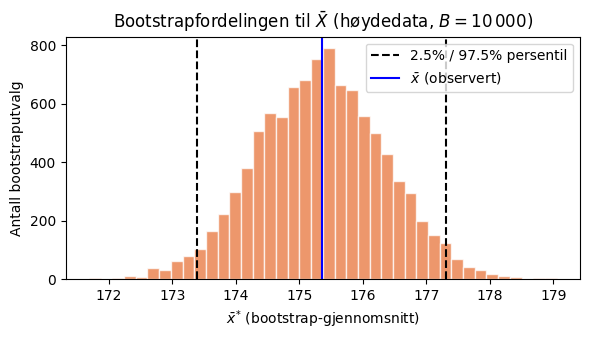

In [5]:
fig, ax = plt.subplots()
ax.hist(bootstrap_means, bins=40, color="#E8743B", alpha=0.75, edgecolor="white")
ax.axvline(ki_boot[0], color="black", linestyle="--", label="2.5% / 97.5% persentil")
ax.axvline(ki_boot[1], color="black", linestyle="--")
ax.axvline(xbar, color="blue", linestyle="-", label=r"$\bar x$ (observert)")
ax.set_xlabel(r"$\bar x^{*}$ (bootstrap-gjennomsnitt)")
ax.set_ylabel("Antall bootstraputvalg")
ax.set_title("Bootstrapfordelingen til $\\bar X$ (høydedata, $B=10\\,000$)")
ax.legend()
plt.tight_layout()
plt.show()

**Sammenligning:** Det klassiske $t$-intervallet og bootstrap-intervallet er
her nesten identiske — nettopp fordi $n=100$ er stort og dataene ikke er svært
skjeve, slik at sentralgrensesetningen fungerer godt. Poenget med bootstrap er
at metoden gir et fornuftig konfidensintervall *selv når* denne antakelsen er
tvilsom, eller når vi ikke har noen enkel formel for standardfeilen.

### Bonus: bootstrap-konfidensintervall for en andel (jf. oppgave 17.6)

In [6]:
# Vi simulerer "rådataene" bak oppgave 17.6: n = 1388 kvinner, 212 røykere (kode 1),
# resten ikke-røykere (kode 0). Rekkefølgen er tilfeldig og påvirker ikke andelen.
n_royk, x_royk = 1388, 212
royk_data = np.concatenate([np.ones(x_royk), np.zeros(n_royk - x_royk)])

B = 10_000
rng = np.random.default_rng(2026)
bootstrap_props = np.empty(B)
for b in range(B):
    resample = rng.choice(royk_data, size=n_royk, replace=True)
    bootstrap_props[b] = resample.mean()

ki_boot_p = np.percentile(bootstrap_props, [2.5, 97.5])

# Klassisk (Wald) KI til sammenligning, jf. oppgave 17.6b
phat = x_royk / n_royk
se_p = np.sqrt(phat * (1 - phat) / n_royk)
z_star = stats.norm.ppf(0.975)
ki_classic_p = (phat - z_star * se_p, phat + z_star * se_p)

print(f"phat = {phat:.4f}")
print(f"Klassisk 95% KI  : [{ki_classic_p[0]:.4f}, {ki_classic_p[1]:.4f}]")
print(f"Bootstrap 95% KI : [{ki_boot_p[0]:.4f}, {ki_boot_p[1]:.4f}]")

phat = 0.1527
Klassisk 95% KI  : [0.1338, 0.1717]
Bootstrap 95% KI : [0.1340, 0.1715]


Igjen ser vi at bootstrap-intervallet og det klassiske intervallet stemmer
godt overens — en fin sjekk på at begge metodene fungerer som de skal når
utvalgsstørrelsen er stor nok.

---
# Utvidelse: Ensidig ANOVA (flere enn to grupper)

Kap. 18 ga oss verktøy for å sammenligne **to** gruppegjennomsnitt. Dette
avsnittet utvider ideen til **tre eller flere** grupper med **ensidig
Analysis of Variance (ANOVA)** — basert på Kaganovskiy, *Applied Statistics
with Python* (kap. om ANOVA).

Vi dekker:

1. Hvorfor gjentatte parvise $t$-tester er en dårlig idé (inflatert type I-feil).
2. Hypoteser, antakelser og grunnideen bak ANOVA (variansanalyse for å teste gjennomsnitt).
3. Et lite, manuelt regnet eksempel med tre klasser.
4. Et ekte datasett (HELPrct): depresjonsscore etter rusmiddel, med ANOVA-tabell, effektstørrelse og Tukeys HSD-post-hoc-test.

## Hvorfor ikke bare gjøre parvise $t$-tester?

Med $k$ grupper og $K=\binom{k}{2}$ parvise $t$-tester på $5\,\%$-nivå er
sannsynligheten for **minst én** falsk positiv (type I-feil), selv om alle
gruppene er identiske:

$$ P(\text{minst én signifikant ved en tilfeldighet}) = 1-0.95^{K}. $$

In [7]:
for k in [3, 5, 25]:
    K = k * (k - 1) // 2   # antall parvise sammenligninger
    P = 1 - 0.95**K
    print(f"k = {k:2d} grupper -> K = {K:3d} par -> P(minst en falsk positiv) = {P:.4f}")

k =  3 grupper -> K =   3 par -> P(minst en falsk positiv) = 0.1426
k =  5 grupper -> K =  10 par -> P(minst en falsk positiv) = 0.4013
k = 25 grupper -> K = 300 par -> P(minst en falsk positiv) = 1.0000


Med $k=25$ identiske grupper er vi så godt som garantert å finne
«signifikante» forskjeller ved ren tilfeldighet. La oss illustrere dette med
en simulering: 25 klasser à 30 elever, alle trukket fra **samme**
normalfordeling ($\mu=70,\ \sigma=20$).

In [8]:
import numpy as np
from scipy.stats import t as t_dist
import math

rng = np.random.default_rng(2026)
mu, sigma, k, n, alpha = 70, 20, 25, 30, 0.05

xbar = np.zeros(k + 1)
s = np.zeros(k + 1)
for j in range(1, k + 1):
    scores = rng.normal(loc=mu, scale=sigma, size=n)
    xbar[j] = scores.mean()
    s[j] = scores.std(ddof=1)

numsignif = 0
for i in range(1, k):
    for j in range(i + 1, k + 1):
        x1, x2 = xbar[i], xbar[j]
        s1, s2 = s[i], s[j]
        n1 = n2 = n
        sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
        SE = sp * np.sqrt(1 / n1 + 1 / n2)
        df1 = n1 + n2 - 2
        T = (x1 - x2) / SE
        p_value = 2 * (1 - t_dist.cdf(abs(T), df=df1))
        if p_value < alpha:
            numsignif += 1

K = math.comb(k, 2)
print(f"Av K = {K} parvise sammenligninger var {numsignif} 'signifikante'")
print(f"Andel = {numsignif/K:.3f}  (alle 25 gruppene er i virkeligheten identiske!)")

Av K = 300 parvise sammenligninger var 12 'signifikante'
Andel = 0.040  (alle 25 gruppene er i virkeligheten identiske!)


Selv om **ingen** av de 25 klassene faktisk er forskjellige, dukker det
opp en rekke "signifikante" par bare av ren tilfeldighet — dette kalles
**data snooping / data fishing**, og er nettopp grunnen til at vi trenger en
egen omnibustest.

## Ensidig ANOVA: hypoteser og grunnidé

$$ H_0:\ \mu_1=\mu_2=\dots=\mu_k \qquad\text{mot}\qquad H_A:\ \text{minst én } \mu_i \text{ er forskjellig}. $$

**Antakelser:** (1) uavhengige observasjoner, (2) tilnærmet normalfordeling i
hver gruppe, (3) lik populasjonsvarians i alle gruppene. ANOVA er robust mot
moderate brudd på (2) og (3).

**Grunnidé:** hvis variasjonen *mellom* gruppene ($SSG$) er stor
sammenlignet med variasjonen *innad* i gruppene ($SSE$), er gjennomsnittene
trolig forskjellige:

$$ SSG=\sum_{i=1}^k n_i(\bar x_i-\bar x)^2,\qquad SSE=\sum_{i=1}^k (n_i-1)s_i^2,\qquad SST=SSG+SSE. $$

$$ MSG=\frac{SSG}{df_G},\ df_G=k-1 \qquad MSE=\frac{SSE}{df_E},\ df_E=n-k \qquad F_{obs}=\frac{MSG}{MSE}\sim F_{df_G,df_E}. $$

Effektstørrelsen er $\eta^2 = SSG/SST$ (Cohens tommelfingerregler: $0.01$
liten, $0.06$ middels, $0.14$ stor).

## Eksempel 1: tre små klasser (manuell utregning)

Poengsummer for tre små klasser A, B og C:

In [9]:
A = [79, 74, 67, 48, 74, 67]
B = [92, 84, 73, 84, 74]
C = [62, 74, 81, 62]

groups = {"A": A, "B": B, "C": C}
means = {g: np.mean(x) for g, x in groups.items()}
stds  = {g: np.std(x, ddof=1) for g, x in groups.items()}
ns    = {g: len(x) for g, x in groups.items()}

grand_mean = np.mean(A + B + C)
n_total = len(A) + len(B) + len(C)
k = len(groups)

print("Gruppegjennomsnitt:", {g: round(m, 2) for g, m in means.items()})
print("Gruppe-std:", {g: round(s, 2) for g, s in stds.items()})
print(f"Total-gjennomsnitt (grand mean) = {grand_mean:.2f}")

Gruppegjennomsnitt: {'A': np.float64(68.17), 'B': np.float64(81.4), 'C': np.float64(69.75)}
Gruppe-std: {'A': np.float64(10.91), 'B': np.float64(7.92), 'C': np.float64(9.39)}
Total-gjennomsnitt (grand mean) = 73.00


In [10]:
# Sum of squares between (SSG) og within (SSE)
SSG = sum(ns[g] * (means[g] - grand_mean) ** 2 for g in groups)
df_G = k - 1
MSG = SSG / df_G

SSE = sum((ns[g] - 1) * stds[g] ** 2 for g in groups)
df_E = n_total - k
MSE = SSE / df_E

F_obs = MSG / MSE
from scipy import stats
p_value = stats.f.sf(F_obs, df_G, df_E)

SST = SSG + SSE
eta2 = SSG / SST

print(f"SSG = {SSG:.2f}   df_G = {df_G}   MSG = {MSG:.2f}")
print(f"SSE = {SSE:.2f}   df_E = {df_E}   MSE = {MSE:.2f}")
print(f"F_obs = {F_obs:.2f}")
print(f"p-verdi = {p_value:.3f}")
print(f"eta^2 = {eta2:.3f}")

SSG = 535.22   df_G = 2   MSG = 267.61
SSE = 1110.78   df_E = 12   MSE = 92.57
F_obs = 2.89
p-verdi = 0.094
eta^2 = 0.325


In [11]:
# Sammenlign med scipy sin innebygde ANOVA-funksjon
F_check, p_check = stats.f_oneway(A, B, C)
print(f"scipy.stats.f_oneway: F = {F_check:.4f}, p = {p_check:.4f}")

scipy.stats.f_oneway: F = 2.8910, p = 0.0944


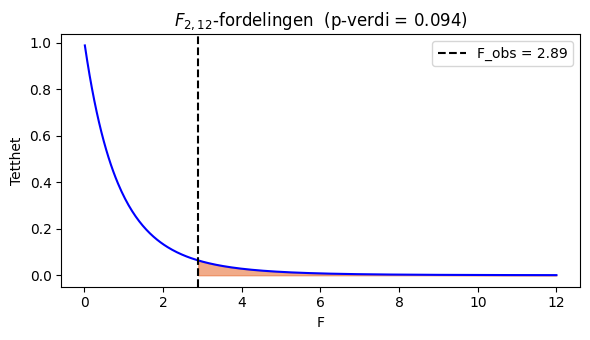

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
x = np.linspace(0.01, 12, 400)
ax.plot(x, stats.f.pdf(x, df_G, df_E), color="blue")
xr = np.linspace(F_obs, 12, 200)
ax.fill_between(xr, stats.f.pdf(xr, df_G, df_E), color="#E8743B", alpha=0.6)
ax.axvline(F_obs, color="black", linestyle="--", label=f"F_obs = {F_obs:.2f}")
ax.set_xlabel("F")
ax.set_ylabel("Tetthet")
ax.set_title(f"$F_{{{df_G},{df_E}}}$-fordelingen  (p-verdi = {p_value:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

**Konklusjon:** $F_{obs}\approx2.89$, $p\approx0.094>0.05$ $\Rightarrow$ vi
kan **ikke forkaste** $H_0$ — ikke overraskende med så små utvalg. Likevel er
$\eta^2\approx0.33$, en *stor* effekt: dette illustrerer at statistisk
signifikans og effektstørrelse er to forskjellige ting, akkurat som i kap.
"Effektstørrelse" tidligere i kurset.

## Eksempel 2: ekte data — depresjon og rusmiddel (HELPrct)

Vi bruker HELPrct-datasettet (Health Evaluation and Linkage to Primary Care)
til å teste om gjennomsnittlig depresjonsscore (`cesd`) er forskjellig
mellom brukere av alkohol, kokain og heroin, på $\alpha=0.01$-nivå.

$$ H_0:\ \mu_{\text{alkohol}}=\mu_{\text{kokain}}=\mu_{\text{heroin}} \qquad H_A:\ \text{minst én er forskjellig}. $$

In [13]:
import pandas as pd

url = "https://raw.githubusercontent.com/leonkag/Statistics0/main/HELPrct.csv"
mydata = pd.read_csv(url)

print("Gjennomsnitt per gruppe:")
print(mydata.groupby("substance")["cesd"].mean().round(2))
print("\nStandardavvik per gruppe:")
print(mydata.groupby("substance")["cesd"].std(ddof=1).round(2))
print("\nUtvalgsstørrelse per gruppe:")
print(mydata.groupby("substance")["cesd"].size())

Gjennomsnitt per gruppe:
substance
alcohol    34.37
cocaine    29.42
heroin     34.87
Name: cesd, dtype: float64

Standardavvik per gruppe:
substance
alcohol    12.05
cocaine    13.40
heroin     11.20
Name: cesd, dtype: float64

Utvalgsstørrelse per gruppe:
substance
alcohol    177
cocaine    152
heroin     124
Name: cesd, dtype: int64


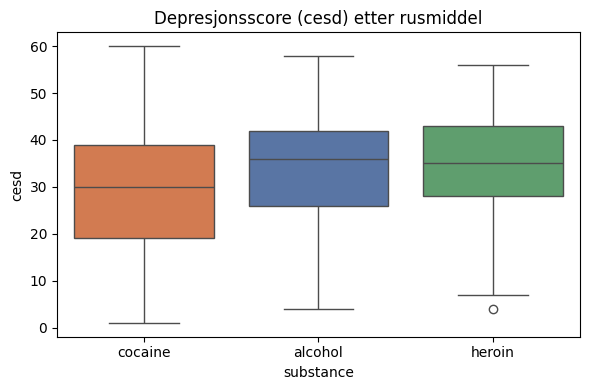

In [14]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="substance", y="cesd", data=mydata, ax=ax, hue="substance",
            palette=["#E8743B", "#4C72B0", "#55A868"], legend=False)
ax.set_title("Depresjonsscore (cesd) etter rusmiddel")
plt.tight_layout()
plt.show()

### Sjekk av ANOVA-antakelsene (Levene og Shapiro)

In [15]:
group1 = mydata.loc[mydata["substance"] == "alcohol", "cesd"]
group2 = mydata.loc[mydata["substance"] == "cocaine", "cesd"]
group3 = mydata.loc[mydata["substance"] == "heroin", "cesd"]

levene_result = stats.levene(group1, group2, group3)
print("Levene (lik varians):", levene_result)

print("\nShapiro (normalitet) per gruppe:")
for label, g in zip(["alkohol", "kokain", "heroin"], [group1, group2, group3]):
    print(f"  {label}: {stats.shapiro(g)}")

Levene (lik varians): LeveneResult(statistic=np.float64(2.4620467678752496), pvalue=np.float64(0.08640810091619187))

Shapiro (normalitet) per gruppe:
  alkohol: ShapiroResult(statistic=np.float64(0.9864528481125129), pvalue=np.float64(0.08590054335177581))
  kokain: ShapiroResult(statistic=np.float64(0.984907377964012), pvalue=np.float64(0.09624909671465955))
  heroin: ShapiroResult(statistic=np.float64(0.9816540424122983), pvalue=np.float64(0.09046788941466044))


Alle $p$-verdier er $>0.05$: verken Levene- eller Shapiro-testene gir
grunn til bekymring, så ANOVA-antakelsene ser ut til å holde godt nok her.

### ANOVA-tabellen og effektstørrelse

In [16]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols("cesd ~ substance", data=mydata).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table.round(4))

SSG = anova_table["sum_sq"].iloc[0]
SSE = anova_table["sum_sq"].iloc[1]
eta2 = SSG / (SSG + SSE)
print(f"\nEffektstørrelse eta^2 = {eta2:.3f}")

              df      sum_sq    mean_sq       F  PR(>F)
substance    2.0   2704.1121  1352.0561  8.9363  0.0002
Residual   450.0  68084.3779   151.2986     NaN     NaN

Effektstørrelse eta^2 = 0.038


**Konklusjon:** $F(2,450)=8.94$, $p=0.0002<0.01=\alpha$
$\Rightarrow$ vi **forkaster** $H_0$: depresjonsscoren er ikke lik i alle tre
gruppene. Effektstørrelsen $\eta^2\approx0.038$ er liten/middels — statistisk
signifikant, men rusmiddel forklarer bare ca. 3.8 % av variasjonen i
depresjonsscore.

### Hvilke grupper er forskjellige? Tukeys HSD-post-hoc-test

In [17]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

post_hoc = pairwise_tukeyhsd(mydata["cesd"], mydata["substance"])
print(post_hoc)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
alcohol cocaine  -4.9518 0.0009 -8.1504 -1.7533   True
alcohol  heroin   0.4981 0.9362 -2.8892  3.8853  False
cocaine  heroin   5.4499 0.0008  1.9498    8.95   True
------------------------------------------------------


**Tolkning:** kokain-gruppen har en signifikant lavere gjennomsnittlig
depresjonsscore enn både alkohol- og heroin-gruppen ($p$-adj $<0.01$ for
begge par), mens alkohol og heroin ikke er signifikant forskjellige fra
hverandre ($p$-adj $=0.936$). Dette stemmer godt med boksplottet over.

**Merk om post-hoc-tester:** Etter en signifikant ANOVA er det fortsatt ikke
lov å gjøre ujusterte parvise $t$-tester (jf. type I-feil-problemet innledningsvis).
Tukeys HSD-test justerer $p$-verdiene for at vi gjør flere sammenligninger
samtidig, og er derfor et mer presist verktøy enn f.eks. en enkel
Bonferroni-korreksjon ($\alpha/K$), som ofte er unødvendig konservativ.